In [2]:
import pandas as pd


df = pd.read_csv('Social_Network_Ads.csv')
df.sample(5)
print(df.dtypes)

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object


Standard scalar + One hot encoding

In [11]:
from sklearn.compose import ColumnTransformer

# Column groups
def preprocess_data(
    df,
    num_cols,
    cat_cols,
    num_processor,
    cat_processor,
    id_col="User ID",
    target_col="Purchased"
):
    """
    Flexible preprocessing function
    """

    # Column transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_processor, num_cols),
            ("cat", cat_processor, cat_cols)
        ]
    )

    # Fit and transform
    transformed = preprocessor.fit_transform(df)

    # Get categorical feature names
    cat_feature_names = []
    if hasattr(preprocessor.named_transformers_["cat"], "get_feature_names_out"):
        cat_feature_names = list(
            preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
        )
    else:
        cat_feature_names = cat_cols

    # Final column names
    new_cols = num_cols + cat_feature_names

    # Convert to DataFrame
    transformed_df = pd.DataFrame(
        transformed,
        columns=new_cols,
        index=df.index
    )

    # Attach ID and target
    final_df = pd.concat(
        [df[[id_col, target_col]], transformed_df],
        axis=1
    )

    return final_df, preprocessor


In [16]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, OrdinalEncoder

num_cols = ["Age", "EstimatedSalary"]
cat_cols = ["Gender"]

df1, prep1 = preprocess_data(
    df,
    num_cols,
    cat_cols,
    StandardScaler(),
    OneHotEncoder(drop="first")
)

print(df1)

df2, prep1 = preprocess_data(
    df,
    num_cols,
    cat_cols,
    RobustScaler(),
    OrdinalEncoder()
)

print(df2)


      User ID  Purchased       Age  EstimatedSalary  Gender_Male
0    15624510          0 -1.781797        -1.490046          1.0
1    15810944          0 -0.253587        -1.460681          1.0
2    15668575          0 -1.113206        -0.785290          0.0
3    15603246          0 -1.017692        -0.374182          0.0
4    15804002          0 -1.781797         0.183751          1.0
..        ...        ...       ...              ...          ...
395  15691863          1  0.797057        -0.844019          0.0
396  15706071          1  1.274623        -1.372587          1.0
397  15654296          1  1.179110        -1.460681          0.0
398  15755018          0 -0.158074        -1.078938          1.0
399  15594041          1  1.083596        -0.990844          0.0

[400 rows x 5 columns]
      User ID  Purchased       Age  EstimatedSalary  Gender
0    15624510          0 -1.107692        -1.133333     1.0
1    15810944          0 -0.123077        -1.111111     1.0
2    15668575   

Lets compare robust and standrad scalar


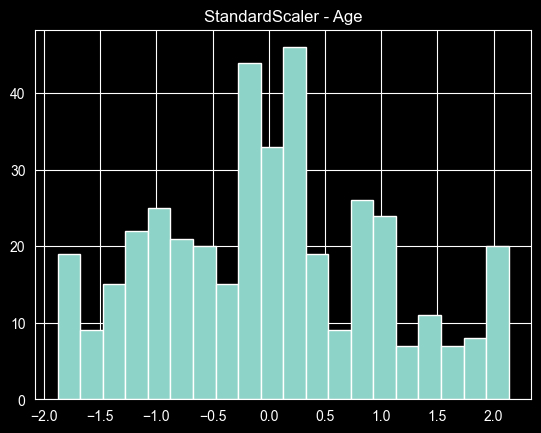

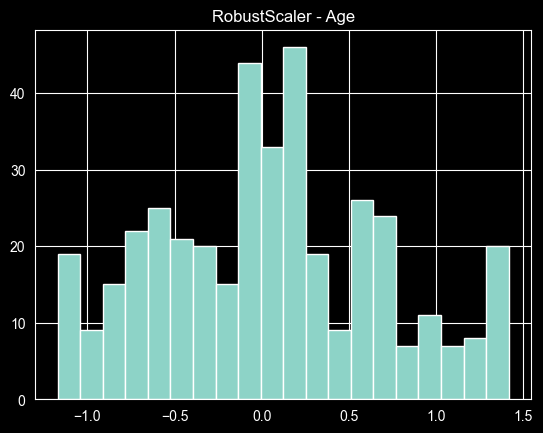

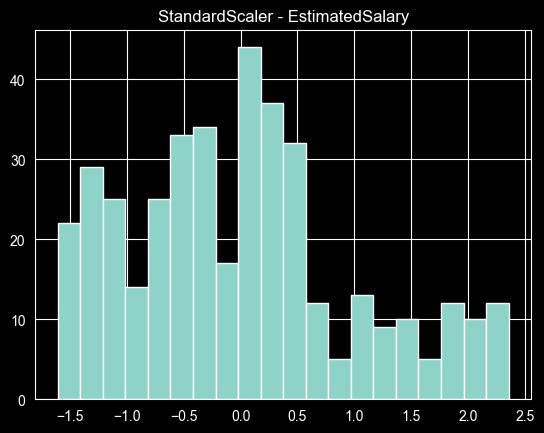

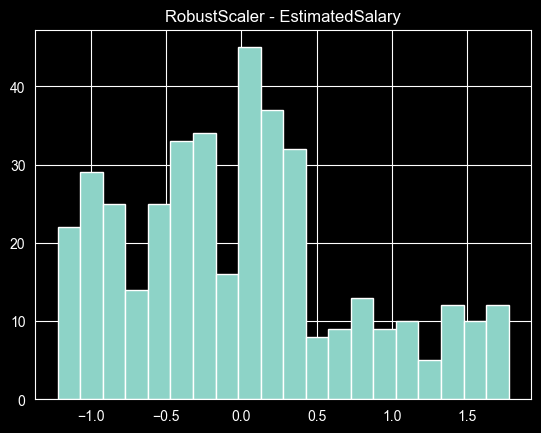

In [17]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    plt.hist(df1[col], bins=20)
    plt.title(f"StandardScaler - {col}")
    plt.show()

    plt.figure()
    plt.hist(df2[col], bins=20)
    plt.title(f"RobustScaler - {col}")
    plt.show()

Vectorizer
CoynterVectorizer
TfIdfvectorizer